In [262]:
%reload_ext autoreload
%autoreload 2
%autoawait off

from squant.models import BsHistory
from squant.slots import get_bs_instruments, get_bs_histories

class HistoryLoader(object):
    def __init__(self):
        pass
    
    def __getitem__(self, key):
        BsHistory.objects.filter(**key)


<ipython-input-263-dfc5eeefbb2c>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quotes['time'] = quotes['time'].map(lambda x: mpdates.date2num(datetime.datetime.strptime(x, '%Y-%m-%dT%H:%M:%SZ')))


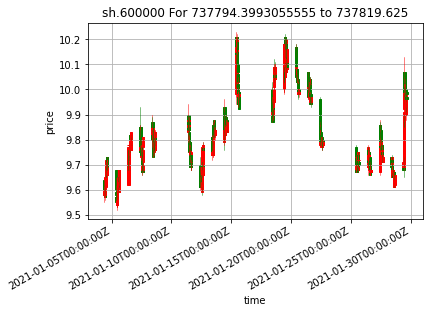

In [263]:
import datetime
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.dates as mpdates
from mplfinance.original_flavor import candlestick_ohlc
#from matplotlib import MultipleLocator

def graph_histories(histories):
    #根据指定代码和时间范围，获取股票数据
    df = pd.DataFrame(histories)
    
    quotes = df[['time', 'open', 'high',  'low', 'close', 'code']]
    quotes['time'] = quotes['time'].map(lambda x: mpdates.date2num(datetime.datetime.strptime(x, '%Y-%m-%dT%H:%M:%SZ')))
    
    #设置大小，共享x坐标轴
    fig, ax = plt.subplots()
    #调用方法，绘制K线图 
    candlestick_ohlc(
        ax,
        quotes.values,
        colorup='red', 
        colordown='green'
    )
    
    #ax.set_title('shshshs')#设置子图标题
    #df['Close'].rolling(window=3).plot(ax=axPrice,color="red",label='3天均线')
    #df['Close'].rolling(window=5).plot(ax=axPrice,color="blue",label='5天均线')
    #df['Close'].rolling(window=10).plot(ax=axPrice,color="green",label='10天均线')
    #axPrice.legend(loc='best') #绘制图例
    #axPrice.set_ylabel("价格（单位：元）")
    #axPrice.grid(True) #带网格线
    #如下绘制成交量子图
    #直方图表示成交量，用for循环处理不同的颜色
    #for index, row in df.iterrows():
    #    if(row['close'] >= row['open']):
    #        axVol.bar(row['time'],row['Volume']/1000000,width = 0.5,color='red')
    #    else:    
    #        axVol.bar(row['Date'],row['Volume']/1000000,width = 0.5,color='green')
    #axVol.set_ylabel("成交量（单位：亿手）")#设置y轴标题
    #axVol.set_title("600895张江高科成交量")#设置子图的标题
    #axVol.set_ylim(0,df['Volume'].max()/100000000*1.2)#设置y轴范围
    #xmajorLocator = MultipleLocator(5) #将x轴主刻度设置为5的倍数
    #axVol.xaxis.set_major_locator(xmajorLocator)
    #axVol.grid(True) #带网格线
    #旋转x轴的展示文字角度
    #for xtick in axVol.get_xticklabels():
    #    xtick.set_rotation(15)
    #plt.rcParams['font.sans-serif']=['SimHei']
    
    # allow grid
    ax.grid(True)

    # Setting labels
    ax.set_xlabel('time')
    ax.set_ylabel('price')

    # setting title
    plt.title(
        '{} For {} to {}'.format(
            quotes.loc[[0], 'code'].values[0],
            quotes['time'].min(), 
            quotes['time'].max()
        )
    )

    # Formatting Date
    date_format = mpdates.DateFormatter('%Y-%m-%dT%H:%M:%SZ')
    ax.xaxis.set_major_formatter(date_format)
    fig.autofmt_xdate()

    #fig.tight_layout()
    plt.show()
    
import random

instruments = get_bs_instruments()

ikey = random.randint(0, 10)

ins = instruments[ikey]

histories = get_bs_histories(ins['code'], '5', '2021-01-01', '2021-02-01')

graph_histories(histories)